# 05 — Số thực và lượng tử hoá

Cổng 3 của dự án cho một kết quả nghe ngược đời: nf4 nén mô hình xuống còn khoảng
**một phần tư** số bit, giảm **55% bộ nhớ**, nhưng **không nhanh hơn** — thậm chí chậm
hơn 8%. Còn int8 thì chậm hơn **2,6 lần**. Notebook này giải thích vì sao, bắt đầu từ
cách máy tính lưu một con số thực.

Nền tảng cần có: notebook 04 (compute-bound và memory-bound, mô hình roofline). Entropy
(bạn đã vững) được dùng ở mục 5.

| Mục | Nội dung |
|---|---|
| 1 | Bộ nhớ của mô hình = số tham số × số byte mỗi tham số |
| 2 | Số dấu phẩy động: fp32, fp16, bf16 |
| 3 | Lượng tử hoá số nguyên: absmax và độ mịn của thang đo |
| 4 | Giá trị ngoại lai trong activation, và vì sao int8 chậm |
| 5 | NF4: đặt mức lượng tử theo phân phối của trọng số |
| 6 | Tốc độ: dự đoán của roofline, và giới hạn thứ ba là CPU |

In [1]:
import glob, json, math, os, sys, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from safetensors import safe_open

sys.path.insert(0, "..")                      # main-branch code lives one level up
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (7, 3.2), "figure.dpi": 110})
dev = "cuda"

WEIGHTS = glob.glob(os.path.expanduser(
    "~/.cache/huggingface/hub/models--HuggingFaceTB--SmolVLM-Instruct/snapshots/*/model.safetensors"))[0]

def timed(fn, warmup=5, reps=30):
    """Median time in microseconds, measured with CUDA events."""
    for _ in range(warmup):
        fn()
    ts = []
    for _ in range(reps):
        s, e = torch.cuda.Event(True), torch.cuda.Event(True)
        torch.cuda.synchronize(); s.record(); fn(); e.record(); torch.cuda.synchronize()
        ts.append(s.elapsed_time(e))
    return float(np.median(ts)) * 1e3

def decode_profile(model, inputs, k=17):
    """Per-token decode cost, from the difference between generating k tokens and 1 token.

    Returns wall-clock ms, GPU kernel ms, CPU ms (all ops, as seen by the profiler),
    kernel launches, and CPU ms spent inside bitsandbytes ops.
    """
    import time
    from torch.profiler import profile, ProfilerActivity
    def run(n):
        g = lambda: model.generate(**inputs, max_new_tokens=n, min_new_tokens=n, do_sample=False)
        g(); walls = []
        for _ in range(3):
            torch.cuda.synchronize(); t = time.perf_counter(); g(); torch.cuda.synchronize()
            walls.append((time.perf_counter() - t) * 1e3)
        # Two separate profiles: with both activities on, device time is double-counted.
        with profile(activities=[ProfilerActivity.CUDA]) as prof:
            g(); torch.cuda.synchronize()
        gpu = sum(e.self_device_time_total for e in prof.key_averages()) / 1e3
        with profile(activities=[ProfilerActivity.CPU]) as prof:
            g(); torch.cuda.synchronize()
        ev = prof.key_averages()
        return np.array([float(np.median(walls)), gpu,
                         sum(e.self_cpu_time_total for e in ev) / 1e3,
                         sum(e.count for e in ev if e.key in ("cudaLaunchKernel", "cuLaunchKernel", "cudaLaunchKernelExC")),
                         sum(e.self_cpu_time_total for e in ev if "bitsandbytes" in e.key) / 1e3])
    per_tok = (run(k) - run(1)) / (k - 1)
    return dict(zip(["wall", "gpu", "cpu", "launches", "bnb_cpu"], per_tok))

gate3 = json.loads(open("../results/gate3_quant.json").read())
for mode, v in gate3.items():
    print(f"{mode:<5} median {v['latency_ms']['median']:6.0f} ms | peak VRAM {v['peak_vram_mb']:5.0f} MiB")

bf16  median    907 ms | peak VRAM  4805 MiB
fp16  median    927 ms | peak VRAM  4805 MiB
int8  median   2340 ms | peak VRAM  3008 MiB
nf4   median    922 ms | peak VRAM  1905 MiB


## 1. Bộ nhớ = số tham số × số byte

Trọng số chiếm phần lớn bộ nhớ khi suy luận. Đếm tham số trực tiếp từ phần đầu file
`model.safetensors` (chỉ đọc hình dạng tensor, không nạp dữ liệu):

In [2]:
groups = {}
with safe_open(WEIGHTS, "pt") as sf:
    shapes = {k: sf.get_slice(k).get_shape() for k in sf.keys()}
for k, shp in shapes.items():
    g = k.split(".")[1] if k.startswith("model.") else k.split(".")[0]
    groups[g] = groups.get(g, 0) + math.prod(shp)
total = sum(groups.values())
for g, c in sorted(groups.items(), key=lambda kv: -kv[1]):
    print(f"{g:<13} {c / 1e6:8.1f} M params")
print(f"{'total':<13} {total / 1e9:8.3f} B params -> bf16: {2 * total / 2**20:,.0f} MiB")

text_model      1711.4 M params
vision_model     413.0 M params
lm_head          100.7 M params
connector         21.2 M params
total            2.246 B params -> bf16: 4,284 MiB


2,25 tỉ tham số × 2 byte (bf16) ≈ 4.280 MiB. Đỉnh đo được là 4.805 MiB: khoảng 500 MiB
còn lại là activation, KV cache (notebook 04: 235 MiB) và vùng nhớ tạm của các kernel.

Muốn giảm bộ nhớ, cách trực tiếp nhất là giảm **số byte mỗi tham số**. Để hiểu có thể
giảm đến đâu, cần biết một con số được lưu thế nào.

## 2. Số dấu phẩy động

Một số dấu phẩy động gồm ba phần: **dấu** $s$ (1 bit), **số mũ** $e$ ($E$ bit), và
**phần định trị** $f$ ($M$ bit). Giá trị của nó (với số "bình thường") là

$$x = (-1)^{s} \times 2^{\,e - \text{bias}} \times \Big(1 + \frac{f}{2^{M}}\Big)$$

- Số bit mũ $E$ quyết định **phạm vi**: số lớn nhất khoảng $2^{2^{E-1}}$.
- Số bit định trị $M$ quyết định **độ chính xác**: khoảng cách giữa 1 và số kế tiếp
  là $\varepsilon = 2^{-M}$, nên sai số làm tròn tương đối tối đa là $\varepsilon/2$.

**Ký hiệu mới**
- $s, e, f$: bit dấu, số mũ, phần định trị · $E, M$: số bit mũ, số bit định trị
- bias: hằng số trừ vào số mũ để biểu diễn được mũ âm ($2^{E-1}-1$)
- $\varepsilon$: machine epsilon — độ chính xác tương đối của định dạng

In [3]:
print(f"{'format':<9} {'E':>2} {'M':>3} | {'max':>10} {'min normal':>11} {'eps':>10}")
for name, dt, E, M in [("float32", torch.float32, 8, 23), ("float16", torch.float16, 5, 10),
                       ("bfloat16", torch.bfloat16, 8, 7)]:
    fi = torch.finfo(dt)
    print(f"{name:<9} {E:>2} {M:>3} | {fi.max:10.3g} {fi.tiny:11.3g} {fi.eps:10.3g}")

w_one = torch.tensor([0.0213], dtype=torch.bfloat16)
bits = f"{w_one.view(torch.int16).item() & 0xFFFF:016b}"
print(f"\n0.0213 in bf16 = {w_one.item():.6f}; bits: sign {bits[0]} | exponent {bits[1:9]} | mantissa {bits[9:]}")
print("fp16: 70000 ->", torch.tensor(70000.0).half().item(), "| bf16: 70000 ->", torch.tensor(70000.0).bfloat16().item())
print("bf16: 1 + 1/256 ->", (torch.tensor(1.0, dtype=torch.bfloat16) + 1 / 256).item())

format     E   M |        max  min normal        eps
float32    8  23 |    3.4e+38    1.18e-38   1.19e-07
float16    5  10 |   6.55e+04     6.1e-05   0.000977
bfloat16   8   7 |   3.39e+38    1.18e-38    0.00781

0.0213 in bf16 = 0.021240; bits: sign 0 | exponent 01111001 | mantissa 0101110
fp16: 70000 -> inf | bf16: 70000 -> 70144.0
bf16: 1 + 1/256 -> 1.0


Giải mã dãy bit của 0,0213: mũ $01111001_2 = 121$, trừ bias 127 được $2^{-6}$; định trị
$0101110_2 = 46$ cho $1 + 46/128 = 1{,}359$; tích là $0{,}02124$ — số bf16 gần 0,0213 nhất.

Bảng này là toàn bộ câu chuyện của bf16:
- **bf16 giữ nguyên 8 bit mũ của fp32** → cùng phạm vi (tới khoảng $3{,}4 \times 10^{38}$),
  không bao giờ tràn số trong thực tế. Đổi lại chỉ có 7 bit định trị: độ chính xác tương
  đối khoảng $2^{-8} \approx 0{,}4\%$ — cộng $1/256$ vào 1 thì mất luôn.
- **fp16 có 10 bit định trị** (chính xác hơn bf16 8 lần), nhưng chỉ 5 bit mũ: số lớn
  nhất là 65.504. Một activation vượt ngưỡng đó thành `inf`.

Vì mạng nơ-ron chịu được sai số làm tròn nhỏ nhưng **không** chịu được tràn số, bf16 là
định dạng mặc định để huấn luyện và chạy các mô hình hiện nay. SmolVLM được phát hành ở
bf16.

**Đổi bf16 sang fp16 có mất gì không?** fp16 có nhiều bit định trị hơn, nên mọi số bf16
nằm trong phạm vi của fp16 đều đổi được **chính xác**. Chỉ các số quá nhỏ (dưới
$6{,}1 \times 10^{-5}$, vùng "dưới chuẩn" của fp16) hoặc quá lớn mới mất. Đếm trên một
lớp thật:

In [4]:
with safe_open(WEIGHTS, "pt") as sf:
    W = sf.get_tensor("model.text_model.layers.12.mlp.down_proj.weight")    # bf16, 2048 x 8192
exact = (W.half().bfloat16() == W).float().mean().item()
print(f"layer 12 down_proj: {W.shape[0]}x{W.shape[1]}, {100 * exact:.3f}% of weights survive bf16 -> fp16 -> bf16 exactly")
print(f"weights below fp16 min normal: {100 * (W.abs() < torch.finfo(torch.float16).tiny).float().mean():.3f}%")

layer 12 down_proj: 2048x8192, 99.995% of weights survive bf16 -> fp16 -> bf16 exactly
weights below fp16 min normal: 0.058%


Gần như toàn bộ trọng số đổi chính xác. Vậy khi cổng 3 đo được "lệch logit tối đa 5,97"
giữa fp16 và bf16, chênh lệch đó **không** đến từ trọng số mà từ **activation**: mỗi phép
tính trung gian được làm tròn theo hai định dạng khác nhau, và sai số tích luỹ qua 24 lớp.
Lưu ý thêm: "chuẩn" ở đây là bf16 — chính nó cũng là một phép xấp xỉ, kém chính xác hơn
fp16. Chênh lệch 5,97 là khoảng cách giữa **hai** phép xấp xỉ, không phải sai số của fp16.
Tiêu chí quan trọng hơn là **khớp token đầu 100%**: hai định dạng chọn cùng một token.

## 3. Lượng tử hoá số nguyên: absmax

Số nguyên 8 bit chỉ có 256 giá trị ($-128$ đến $127$). Để lưu một nhóm trọng số bằng
int8, chọn một **hệ số tỉ lệ** $\Delta$ sao cho giá trị lớn nhất (theo trị tuyệt đối) của
nhóm rơi đúng vào 127:

$$\Delta = \frac{\max_i |w_i|}{127}, \qquad q_i = \operatorname{round}\Big(\frac{w_i}{\Delta}\Big),
\qquad \hat w_i = \Delta\, q_i$$

Mỗi trọng số giờ chỉ cần 1 byte, cộng một $\Delta$ dùng chung cho cả nhóm. Làm tròn đến
số nguyên gần nhất có sai số tối đa nửa bước, nên $|w_i - \hat w_i| \le \Delta/2$.

Với $b$ bit, số 127 thay bằng $2^{b-1}-1$ (int4: 7 — chỉ 15 mức).

**Ký hiệu mới**
- $\Delta$: hệ số tỉ lệ (bước lượng tử) · $q_i$: số nguyên lưu trữ · $\hat w_i$: giá trị khôi phục
- round: làm tròn đến số nguyên gần nhất · $b$: số bit

**Độ mịn của nhóm** (granularity) quyết định chất lượng. $\Delta$ do phần tử lớn nhất
nhóm quyết định; nếu nhóm có **một** giá trị ngoại lai lớn, $\Delta$ phình ra và mọi phần
tử khác bị làm tròn thô. Nhóm càng nhỏ, ngoại lai càng ít "lây" sang phần tử khác — đổi
lại phải lưu nhiều $\Delta$ hơn. Đo trên lớp thật với ba cách chia nhóm:

In [5]:
def absmax_quant(w, bits, group):
    """Symmetric absmax quantisation. group: 'tensor', 'row' or an int block size."""
    qmax = 2 ** (bits - 1) - 1
    w = w.float()
    if group == "tensor":
        g = w.reshape(1, -1)
    elif group == "row":
        g = w
    else:
        g = w.reshape(-1, group)
    scale = g.abs().amax(dim=1, keepdim=True) / qmax
    return (torch.round(g / scale).clamp(-qmax, qmax) * scale).reshape(w.shape)

def rel_err(w, w_hat):
    w = w.float()
    return ((w - w_hat).norm() / w.norm()).item()

print(f"{'group':<10} {'int8 rel. error':>16} {'int4 rel. error':>16}")
for group in ["tensor", "row", 64]:
    print(f"{str(group):<10} {100 * rel_err(W, absmax_quant(W, 8, group)):15.2f}% "
          f"{100 * rel_err(W, absmax_quant(W, 4, group)):15.2f}%")
Wf = W.float()
print(f"\nmax |w| = {Wf.abs().max():.3f}, std = {Wf.std():.4f} -> max is {Wf.abs().max() / Wf.std():.0f} std away")

group       int8 rel. error  int4 rel. error


tensor                7.07%           94.51%


row                   1.06%           19.10%


64                    0.62%           11.21%

max |w| = 2.781, std = 0.0894 -> max is 31 std away


Sai số tương đối ở đây là $\lVert w - \hat w \rVert / \lVert w \rVert$ (chuẩn Euclid của cả ma
trận). Ba điều rút ra:

1. **Cả tensor dùng chung một $\Delta$ là tệ**: phần tử lớn nhất nằm cách trung bình
   hàng chục độ lệch chuẩn, nên bước lượng tử quá thô với số đông.
   Với int4, một $\Delta$ cho cả tensor gần như **xoá sạch** thông tin (sai số khoảng
   95%: hầu hết trọng số bị làm tròn về 0).
2. **int8 theo hàng đã đủ tốt** (sai số khoảng 1%) — đó là mức bitsandbytes dùng cho
   trọng số int8.
3. **int4 cần khối nhỏ**: ngay cả với khối 64 phần tử, sai số vẫn còn khoảng 11%. Đó là
   lý do mọi phương pháp 4 bit đều lượng tử hoá theo khối, và là động lực cho NF4 ở mục 5.

## 4. Ngoại lai trong activation, và vì sao int8 chậm

Lượng tử hoá trọng số là một nửa câu chuyện. Để nhân ma trận **bằng số nguyên** (nhanh
hơn trên phần cứng), đầu vào $X$ của lớp cũng phải được lượng tử hoá. Và activation có
một tính chất mà trọng số không có: **ngoại lai theo chiều đặc trưng** (feature
outliers) — một số ít chiều của vector ẩn có giá trị lớn hơn hẳn các chiều còn lại, ở
hầu hết mọi token. Bài báo LLM.int8() (Dettmers và cộng sự, 2022) chỉ ra hiện tượng này
trở nên phổ biến ở mô hình lớn.

Đo trên mô hình thật: gắn "hook" vào đầu vào của mọi lớp tuyến tính trong mô hình ngôn
ngữ, chạy một câu hỏi thật, và đếm số chiều đặc trưng có trị tuyệt đối vượt 6 (ngưỡng
mặc định của LLM.int8()).

In [6]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from bench.harness import load_samples, PROMPT

MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to(dev).eval()
sample = load_samples(1, seed=0)[0]
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
inputs = proc(text=proc.apply_chat_template(msg, add_generation_prompt=True),
              images=[sample["image"]], return_tensors="pt").to(dev)

stats = {}
def hook(name):
    def f(mod, args):
        x = args[0].float().reshape(-1, args[0].shape[-1])
        col_max = x.abs().amax(dim=0)
        stats[name] = (int((col_max > 6).sum()), x.shape[1], x.abs().max().item(), x.abs().median().item())
    return f

handles = [m.register_forward_pre_hook(hook(n)) for n, m in model.model.text_model.named_modules()
           if isinstance(m, torch.nn.Linear)]
with torch.no_grad():
    model(**inputs)
for h in handles:
    h.remove()

n_with = sum(v[0] > 0 for v in stats.values())
print(f"linear layers with at least one feature |x| > 6: {n_with}/{len(stats)}")
for name in ["layers.0.self_attn.q_proj", "layers.12.self_attn.q_proj", "layers.12.mlp.down_proj", "layers.23.mlp.down_proj"]:
    k, d, mx, med = stats[name]
    print(f"{name:<28} outlier features {k:>3}/{d}  max |x| {mx:8.1f}  median |x| {med:.3f}")
print(f"largest activation anywhere: {max(v[2] for v in stats.values()):.0f} (fp16 max is 65504)")

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

linear layers with at least one feature |x| > 6: 101/168
layers.0.self_attn.q_proj    outlier features   1/2048  max |x|     11.7  median |x| 0.016
layers.12.self_attn.q_proj   outlier features   5/2048  max |x|     15.7  median |x| 0.113
layers.12.mlp.down_proj      outlier features   1/8192  max |x|      6.3  median |x| 0.046
layers.23.mlp.down_proj      outlier features 1520/8192  max |x|    149.0  median |x| 0.159
largest activation anywhere: 2128 (fp16 max is 65504)


Khoảng 60% số lớp tuyến tính (101 trên 168) có ít nhất một chiều vượt ngưỡng. Thường
chỉ là một vài chiều trên 2048, nhưng giá trị của chúng lớn gấp hàng trăm lần trung vị;
ở lớp cuối cùng, số chiều ngoại lai lên tới hàng nghìn. Nếu lượng tử hoá cả hàng $X$ bằng absmax, các chiều
này quyết định $\Delta$, và mọi chiều bình thường bị làm tròn về 0.

**Cách LLM.int8() xử lý:** tách phép nhân ma trận theo các chiều đặc trưng. Gọi $O$ là
tập các cột của $X$ có ngoại lai:

$$XW = \underbrace{X_{:,O}\,W_{O,:}}_{\text{fp16}} \;+\; \underbrace{X_{:,\bar O}\,W_{\bar O,:}}_{\text{int8}}$$

**Ký hiệu mới**
- $O$: tập chỉ số chiều ngoại lai · $\bar O$: phần còn lại
- $X_{:,O}$: các cột thuộc $O$ của $X$ · $W_{O,:}$: các hàng tương ứng của $W$

Cách này giữ được độ chính xác (cổng 3: khớp token đầu 100%), nhưng **mỗi lần gọi** lớp
tuyến tính phải: tìm cột ngoại lai, lượng tử hoá $X$ theo hàng, làm **hai** phép nhân ma
trận, rồi giải lượng tử và cộng lại. Toàn bộ phần việc thêm đó là lý do int8 chậm hơn
bf16 **2,6 lần** trong cổng 3 — nó được thiết kế để **tiết kiệm bộ nhớ**, không phải để
tăng tốc. (bitsandbytes còn đổi đầu vào bf16 sang fp16 trước khi lượng tử hoá — may là
activation lớn nhất ở trên vẫn nằm trong phạm vi fp16.)

Trước khi giải phóng mô hình bf16, đo sẵn chi phí decode của nó để so với nf4 ở mục 6
(chỉ nạp **một** mô hình mỗi lúc — GPU 6 GB không chứa được hai):

In [7]:
with torch.no_grad():
    dec_bf16 = decode_profile(model, inputs)
print(f"bf16 decode: {dec_bf16['wall']:.1f} ms per token (wall), GPU kernels {dec_bf16['gpu']:.1f} ms")
del model; torch.cuda.empty_cache()

USDT:2026-09-24 16:48:48 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:48:49 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-24 16:48:50 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:48:52 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-24 16:48:58 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:48:58 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop
USDT:2026-09-24 16:48:58 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:48:59 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


bf16 decode: 52.5 ms per token (wall), GPU kernels 44.2 ms


## 5. NF4: đặt mức lượng tử theo phân phối của trọng số

### 5.1. Trọng số có phân phối gần chuẩn

int4 absmax chia đều 15 mức trên đoạn $[-\max, \max]$. Nhưng trọng số không phân bố đều:
chúng dồn quanh 0 theo hình chuông. Chia đều thì các mức ở rìa hầu như không được dùng,
còn vùng đông đúc quanh 0 lại thiếu mức.

Ý tưởng của **NF4** (NormalFloat 4-bit, bài báo QLoRA, Dettmers và cộng sự, 2023): nếu
trọng số trong một khối xấp xỉ phân phối chuẩn, hãy đặt 16 mức tại các **phân vị** của
phân phối chuẩn, để **mỗi mức được dùng với tần suất gần như nhau**.

**Liên hệ với entropy** (bạn đã vững): một mã 4 bit mang tối đa 4 bit thông tin, đạt được
khi 16 mức được dùng **đều nhau** (entropy $H = \log_2 16 = 4$). Mức nào hiếm khi được dùng
là bit lãng phí. Đặt mức theo phân vị chính là cách làm cho phân phối các mức gần đều.

**Dựng bảng NF4.** Với $\Phi^{-1}$ là hàm ngược của hàm tích luỹ chuẩn (notebook 00,
mục 3.1), 8 mức dương lấy tại phân vị của 8 điểm cách đều trong $[0{,}5;\ \delta]$, 7 mức
âm tương tự, cộng mức 0 chính xác, rồi chia cho giá trị lớn nhất để nằm trong $[-1, 1]$.
Hằng số $\delta = 0{,}9677$ được chọn để mức ngoài cùng không rơi vào $\Phi^{-1}(1) = \infty$.

**Ký hiệu mới**
- $\Phi^{-1}$: hàm phân vị của phân phối chuẩn (`torch.special.ndtri`) · $\delta$: phân vị ngoài cùng

In [8]:
import bitsandbytes.functional as bnbF

delta = 0.9677083
pos = torch.special.ndtri(torch.linspace(delta, 0.5, 9, dtype=torch.float64)[:-1])
neg = -torch.special.ndtri(torch.linspace(delta, 0.5, 8, dtype=torch.float64)[:-1])
levels = torch.cat([pos, torch.zeros(1, dtype=torch.float64), neg]).sort().values
levels = (levels / levels.abs().max()).float()
bnb_levels = bnbF.get_4bit_type("nf4", "cpu")
print("built  :", [round(v, 4) for v in levels.tolist()])
print("bnb    :", [round(v, 4) for v in bnb_levels.tolist()])
print(f"max difference: {(levels - bnb_levels).abs().max():.2e}")

built  : [-1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.091, 0.0, 0.0796, 0.1609, 0.2461, 0.3379, 0.4407, 0.5626, 0.723, 1.0]
bnb    : [-1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911, 0.0, 0.0796, 0.1609, 0.2461, 0.3379, 0.4407, 0.5626, 0.723, 1.0]
max difference: 1.19e-07


Bảng tự dựng khớp với bảng mà bitsandbytes dùng. Để ý các mức dày đặc quanh 0 và thưa
dần ra hai rìa — đúng hình dạng của phân phối chuẩn.

### 5.2. Lượng tử hoá theo khối, và kiểm chứng với bitsandbytes

Quy trình NF4 cho mỗi khối 64 trọng số: chia cho absmax của khối (đưa về $[-1, 1]$), rồi
thay mỗi giá trị bằng **mức gần nhất** trong bảng. Lưu chỉ số mức (4 bit) và absmax.

In [9]:
def nf4_quant(w, block=64):
    g = w.float().reshape(-1, block)
    absmax = g.abs().amax(dim=1, keepdim=True)
    idx = ((g / absmax).unsqueeze(-1) - levels).abs().argmin(dim=-1)   # nearest level
    return idx, absmax

def nf4_dequant(idx, absmax, shape):
    return (levels[idx] * absmax).reshape(shape)

Wg = W.cuda()
levels = levels.cuda()
idx, absmax = nf4_quant(Wg)
W_mine = nf4_dequant(idx, absmax, W.shape)

packed, state = bnbF.quantize_4bit(Wg, blocksize=64, quant_type="nf4")
W_bnb = bnbF.dequantize_4bit(packed, state).float()
print(f"mine vs bitsandbytes: max abs difference {(W_mine - W_bnb).abs().max():.2e}, "
      f"identical: {100 * (W_mine.bfloat16() == W_bnb.bfloat16()).float().mean():.2f}% of weights")

int4 = absmax_quant(Wg, 4, 64)
print(f"relative error, block 64:  int4 absmax {100 * rel_err(Wg, int4):.2f}%   NF4 {100 * rel_err(Wg, W_mine):.2f}%")

def level_entropy(codes, k):
    p = torch.bincount(codes.flatten(), minlength=k).float()
    p = p[p > 0] / p.sum()
    return -(p * p.log2()).sum().item()

int4_codes = torch.round(Wg.float().reshape(-1, 64) / (Wg.float().reshape(-1, 64).abs().amax(1, keepdim=True) / 7)).long() + 7
print(f"entropy of code usage (max 4 bits): int4 absmax {level_entropy(int4_codes, 15):.2f}   NF4 {level_entropy(idx, 16):.2f}")

mine vs bitsandbytes: max abs difference 3.74e-03, identical: 100.00% of weights
relative error, block 64:  int4 absmax 11.21%   NF4 9.30%
entropy of code usage (max 4 bits): int4 absmax 3.46   NF4 3.86


Ba kết quả:
- Cài đặt tự viết trùng khớp với bitsandbytes: sau khi làm tròn về bf16 (định dạng lớp
  thực sự dùng), 100% trọng số giống hệt. Không có gì bí ẩn trong thư viện — chỉ là bảng
  phân vị cộng làm tròn đến mức gần nhất. (Chênh lệch cỡ 0,004 trước khi làm tròn là do
  hai bên tính trung gian ở độ chính xác khác nhau.)
- Cùng 4 bit, cùng khối 64, NF4 cho **sai số nhỏ hơn** int4 absmax.
- Lý do nằm ở entropy: NF4 dùng 16 mức đều hơn, nên mang nhiều thông tin hơn trên mỗi 4
  bit.

Biểu đồ phân phối trọng số (đã chia absmax của khối) cùng 16 mức NF4:

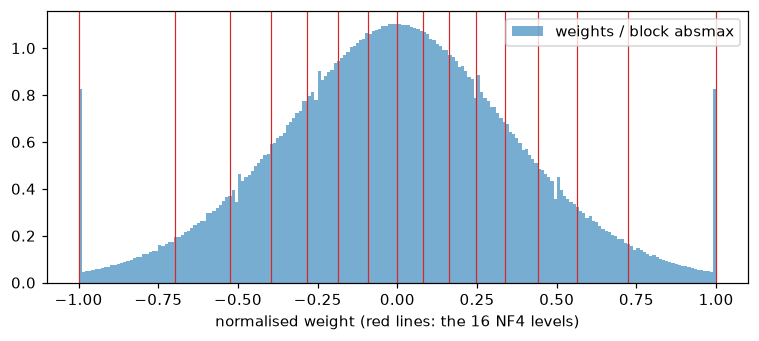

In [10]:
normed = (Wg.float().reshape(-1, 64) / absmax).flatten().cpu().numpy()
plt.hist(normed, bins=200, density=True, alpha=0.6, label="weights / block absmax")
for v in levels.tolist():
    plt.axvline(v, c="C3", lw=0.8)
plt.xlabel("normalised weight (red lines: the 16 NF4 levels)"); plt.legend(); plt.tight_layout(); plt.show()

### 5.3. Chi phí của absmax, và lượng tử hoá kép

Mỗi khối 64 trọng số cần lưu một absmax fp32 (32 bit), tức thêm $32/64 = 0{,}5$ bit cho mỗi
tham số — tăng 12,5% so với 4 bit. **Lượng tử hoá kép** (double quantization) lượng tử hoá
chính các absmax này xuống 8 bit, theo khối 256, với một hằng số fp32 cho mỗi khối:

$$\text{bit mỗi tham số} = 4 + \frac{8}{64} + \frac{32}{64 \times 256} \approx 4{,}127
\quad\text{(so với } 4 + \tfrac{32}{64} = 4{,}5\text{)}$$

Dự án bật tuỳ chọn này (`bnb_4bit_use_double_quant=True` trong `bench/quantize.py`). Dự đoán
bộ nhớ trọng số của cả mô hình nf4: các ma trận của lớp tuyến tính ở dạng 4,127 bit, còn
lại (embedding, `lm_head`, lớp chuẩn hoá, tích chập patch) giữ bf16 — đó là mặc định của
transformers.

In [11]:
SKIP = ("embed_tokens", "lm_head", "position_embedding")      # 2-D, but not linear layers
lin = sum(math.prod(s) for k, s in shapes.items()
          if len(s) == 2 and not any(x in k for x in SKIP))
rest = total - lin
pred_mib = (lin * 4.127 / 8 + rest * 2) / 2**20
print(f"linear-layer weights: {lin / 1e9:.3f} B params (4.127 bits) | rest: {rest / 1e6:.0f} M params (bf16)")
print(f"predicted nf4 weights: {pred_mib:,.0f} MiB   measured peak: {gate3['nf4']['peak_vram_mb']:,.0f} MiB")

linear-layer weights: 2.043 B params (4.127 bits) | rest: 203 M params (bf16)
predicted nf4 weights: 1,393 MiB   measured peak: 1,905 MiB


Phần chênh giữa dự đoán và đỉnh đo được là khoảng 510 MiB — gần đúng bằng phần chênh ở
bf16 ($4\,805 - 4\,284 \approx 520$ MiB). Nghĩa là công thức giải thích đúng phần trọng số, và
phần còn lại (activation, KV cache) không đổi khi lượng tử hoá — hợp lý, vì activation vẫn
là bf16. Lưu ý: phần "giữ bf16" — chủ yếu là embedding và `lm_head`, mỗi cái hơn 100
triệu tham số — chiếm một tỉ trọng lớn bất thường sau khi phần còn lại đã bị nén 4 lần.

## 6. Tốc độ: dự đoán của roofline, và thực tế

Giờ đến câu hỏi chính. Nf4 **không** làm phép nhân bằng số 4 bit: GPU không có lệnh nhân
ma trận 4 bit kiểu này. Mỗi lần gọi, lớp nf4 phải **giải lượng tử** trọng số về bf16,
rồi nhân bằng bf16 như thường. Vậy theo mô hình roofline của notebook 04:

- **Ít token (decode, memory-bound)**: thời gian do số byte đọc quyết định. Đọc 4,127 bit
  thay vì 16 bit → có thể **nhanh hơn tới gần 4 lần**, nếu kernel giải lượng tử ngay
  trong lúc đọc.
- **Nhiều token (prefill, compute-bound)**: thời gian do số FLOP quyết định. FLOP không
  đổi, lại cộng thêm việc giải lượng tử → **chậm hơn**.

Đo một lớp thật (2048 → 8192) ở ba định dạng, với số token từ 1 đến 1251:

In [12]:
import bitsandbytes as bnb

d_in, d_out = 2048, 8192
with safe_open(WEIGHTS, "pt") as sf:
    Wup = sf.get_tensor("model.text_model.layers.12.mlp.up_proj.weight")    # 8192 x 2048

l16 = torch.nn.Linear(d_in, d_out, bias=False, dtype=torch.bfloat16, device=dev)
l16.weight.data.copy_(Wup)
l4 = bnb.nn.Linear4bit(d_in, d_out, bias=False, compute_dtype=torch.bfloat16, quant_type="nf4")
l4.weight = bnb.nn.Params4bit(Wup.clone(), requires_grad=False, quant_type="nf4")
l4 = l4.to(dev)
l8 = bnb.nn.Linear8bitLt(d_in, d_out, bias=False, has_fp16_weights=False, threshold=6.0)
l8.weight = bnb.nn.Int8Params(Wup.clone(), requires_grad=False, has_fp16_weights=False)
l8 = l8.to(dev)

rows = []
with torch.no_grad():
    for T in [1, 4, 16, 64, 256, 1251]:
        x = torch.randn(T, d_in, device=dev, dtype=torch.bfloat16)
        t16, t4, t8 = timed(lambda: l16(x)), timed(lambda: l4(x)), timed(lambda: l8(x))
        rows.append((T, t16, t4, t8))
        print(f"T = {T:>4}: bf16 {t16:6.0f} us | nf4 {t4:6.0f} us ({t16 / t4:4.2f}x) | int8 {t8:6.0f} us ({t16 / t8:4.2f}x)")

MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


...

MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization


T = 1251: bf16   1947 us | nf4   2320 us (0.84x) | int8   2683 us (0.73x)


Ở cấp **một lớp**, kết quả khớp dự đoán của roofline:

- **1 token**: nf4 nhanh hơn bf16. bitsandbytes có kernel riêng cho trường
  hợp này, giải lượng tử ngay trong lúc đọc, nên được lợi từ việc đọc ít byte hơn.
- **Tăng số token**: lợi thế mất ngay từ vài token; đến vài trăm token (vùng prefill) nf4
  **chậm hơn** bf16 gần gấp đôi — thư viện chuyển sang giải lượng tử cả ma trận rồi mới
  nhân. (Hai lần chạy notebook cho tỉ lệ ở 1 token dao động giữa 1,5 và 2,3 lần — một
  phép đo micro-giây đơn lẻ trên GPU laptop khá nhiễu; chiều của kết quả thì ổn định.)
- **int8** chậm hơn ở mọi mức, vì phần việc thêm của LLM.int8() ở mục 4.

Theo đó, nf4 lẽ ra phải làm decode của cả mô hình nhanh hơn. Kiểm chứng trên cả mô hình:

In [13]:
from bench.quantize import load_quantized

model4 = load_quantized(MODEL, "nf4")
with torch.no_grad():
    dec_nf4 = decode_profile(model4, inputs)
print(f"{'per token':<9} {'wall':>8} {'GPU kernels':>12} {'GPU idle':>9}")
for name, d in [("bf16", dec_bf16), ("nf4", dec_nf4)]:
    print(f"{name:<9} {d['wall']:5.1f} ms {d['gpu']:9.1f} ms {100 * (1 - d['gpu'] / d['wall']):8.0f}%")

Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

USDT:2026-09-24 16:49:11 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:49:13 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-24 16:49:14 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:49:16 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-24 16:49:22 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:49:23 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


USDT:2026-09-24 16:49:24 18934:18934 SyncActivityProfilerHandler.cpp:39] profiler_start


USDT:2026-09-24 16:49:24 18934:18934 SyncActivityProfilerHandler.cpp:46] profiler_stop


per token     wall  GPU kernels  GPU idle
bf16       52.5 ms      44.2 ms       16%
nf4        54.1 ms      23.7 ms       56%


Kết quả chia làm hai nửa, và nửa sau là điều mô hình roofline không dự đoán được:

- **Phần việc của GPU giảm đúng như lý thuyết**: tổng thời gian các kernel mỗi token của
  nf4 chỉ khoảng một nửa bf16 (không tới 4 lần, vì `lm_head`, attention và các lớp chuẩn
  hoá vẫn ở bf16, và còn thêm việc giải lượng tử).
- **Nhưng thời gian thực không giảm** — ngang bằng hoặc chậm hơn bf16 — và GPU **ngồi không** phần lớn thời gian.

(Con số tuyệt đối dao động giữa các lần chạy, vì GPU laptop hạ xung khi nóng — notebook 02. Quan hệ giữa hai hàng thì ổn định qua mọi lần chạy khi viết notebook này: kernel nf4 bằng khoảng một nửa bf16, còn tỉ lệ GPU rảnh của nf4 cao gấp nhiều lần.)

### 6.1. Giới hạn thứ ba: CPU

Notebook 02 giải thích rằng GPU chạy **bất đồng bộ**: CPU xếp từng kernel vào hàng đợi,
GPU lấy ra chạy. Mỗi kernel, CPU phải chạy code Python của framework để chuẩn bị rồi phát
lệnh — cỡ vài chục micro-giây. Nếu tổng thời gian CPU cần để phát các kernel của một bước
lớn hơn thời gian GPU chạy chúng, GPU sẽ chạy xong trước và phải chờ. Khi đó công việc bị
**giới hạn bởi CPU** (CPU-bound, hay launch-bound), và làm GPU nhanh hơn không giúp gì:

$$t_{\text{bước}} \approx \max\big(t_{\text{CPU}},\; t_{\text{GPU}}\big)$$

**Ký hiệu mới**
- $t_{\text{CPU}}$: thời gian CPU chạy code và phát toàn bộ kernel của một bước decode
- $t_{\text{GPU}}$: thời gian GPU thực sự chạy các kernel đó

Đếm xem một bước decode gồm những gì, bằng profiler của PyTorch:

In [14]:
print(f"{'per token':<9} {'kernels':>8} {'CPU (profiled)':>15} {'of which bitsandbytes':>22} {'GPU kernels':>12}")
for name, d in [("bf16", dec_bf16), ("nf4", dec_nf4)]:
    print(f"{name:<9} {d['launches']:8.0f} {d['cpu']:12.1f} ms {d['bnb_cpu']:19.1f} ms {d['gpu']:9.1f} ms")

per token  kernels  CPU (profiled)  of which bitsandbytes  GPU kernels
bf16          1017         31.2 ms                 0.0 ms      44.2 ms
nf4           1017         41.0 ms                 5.3 ms      23.7 ms


(Profiler tự nó làm CPU chậm đi, nên cột CPU chỉ dùng để **so sánh tương đối**, không
phải thời gian tuyệt đối.)

Cơ chế hiện ra rõ:
- Một bước decode phát khoảng **một nghìn kernel** — không chỉ 168 lớp tuyến tính, mà cả
  chuẩn hoá, RoPE, cộng residual, nối KV cache ở 24 lớp. Mỗi kernel tốn thời gian CPU, nên
  có một **"sàn CPU"** gần như không phụ thuộc định dạng số.
- Ở **bf16**, GPU chạy lâu (đọc 3,6 GB trọng số mỗi token), đủ để che sàn CPU: GPU gần như
  luôn có việc.
- Ở **nf4**, GPU chạy nhanh hơn hẳn — đúng như roofline dự đoán — nên **lộ ra sàn CPU**.
  bitsandbytes còn nâng sàn đó lên, vì mỗi lần gọi lớp nf4 tốn thêm thời gian CPU.

Phép đo một lớp đơn lẻ ở đầu mục 6 không thấy được hiện tượng này, vì chi phí CPU rải
trên cả nghìn phép tính nhỏ của mô hình chứ không nằm ở một lớp nào. Bài học đo đạc:
**tối ưu một thành phần rồi đo riêng thành phần đó là chưa đủ** — phải đo lại cả hệ thống.

Đây là lý do các hệ thống phục vụ chuyên dụng không chạy mô hình theo kiểu Python gọi
từng lớp một: họ dùng **CUDA graph** (ghi lại cả chuỗi kernel của một bước decode một lần,
rồi phát lại bằng một lệnh duy nhất) và các kernel 4 bit hợp nhất (llama.cpp, vLLM). Khi
sàn CPU được gỡ bỏ, lợi thế băng thông của 4 bit mới thành tốc độ thật.

In [15]:
del model4; torch.cuda.empty_cache()

**Lưu ý đo đạc:** sau khi giải phóng một mô hình bitsandbytes, bộ nhớ GPU không được trả
lại hoàn toàn. Nạp tiếp một mô hình bf16 trong **cùng tiến trình** có thể khiến nó tràn
sang RAM hệ thống (driver trên WSL cho phép điều này) — thời gian tới token đầu tiên vọt
lên hàng giây. Vì vậy notebook đo bf16 **trước** nf4, và `bench/quantize.py` giải phóng
mô hình bf16 trước khi nạp các biến thể khác.

### 6.2. Ghép lại thành con số của cả mô hình

Một lần trả lời câu hỏi ChartQA gồm (bảng phân rã trong README): mã hoá thị giác và
prefill — **compute-bound**, khoảng 80% thời gian — rồi decode vài token. nf4 làm phần
compute-bound chậm đi (thêm giải lượng tử) **và** làm decode chậm đi (giới hạn bởi CPU).
Số liệu 300 mẫu:

In [16]:
nf4_300 = json.loads(open("../results/gate5_nf4_300.json").read())
bf16_300 = json.loads(open("../results/gate2_confirm.json").read())
rows = {}
for name, r in [("bf16", bf16_300), ("nf4", nf4_300)]:
    c = r["configs"]["baseline"]
    rows[name] = (c["prefill_ms"]["median"], c["generate_ms"]["median"])
    print(f"{name:<5} 300 samples: time to first token {rows[name][0]:5.0f} ms | total {rows[name][1]:5.0f} ms "
          f"| after first token {rows[name][1] - rows[name][0]:4.0f} ms | peak VRAM {r['peak_vram_mb']:5.0f} MiB")
print(f"nf4 vs bf16: first token {100 * (rows['nf4'][0] / rows['bf16'][0] - 1):+.0f}%, "
      f"after first token {100 * ((rows['nf4'][1] - rows['nf4'][0]) / (rows['bf16'][1] - rows['bf16'][0]) - 1):+.0f}%, "
      f"total {100 * (rows['nf4'][1] / rows['bf16'][1] - 1):+.0f}%")

bf16  300 samples: time to first token   730 ms | total   908 ms | after first token  179 ms | peak VRAM  5213 MiB
nf4   300 samples: time to first token   760 ms | total   995 ms | after first token  235 ms | peak VRAM  2321 MiB
nf4 vs bf16: first token +4%, after first token +31%, total +10%


Cả hai phần đều chậm hơn, đúng như hai cơ chế ở trên: phần tới token đầu tiên chậm hơn
một chút (compute-bound, thêm giải lượng tử), phần decode chậm hơn nhiều (CPU-bound).

**Khi nào 4 bit thật sự nhanh hơn?** Khi đồng thời có (1) kernel 4 bit hợp nhất với chi
phí CPU thấp, và (2) decode chiếm phần lớn thời gian — câu trả lời dài, lời nhắc ngắn. Ở
bài toán hỏi đáp trên ảnh với bitsandbytes, không điều kiện nào thoả, nên nf4 chỉ mua được
bộ nhớ.

## Tóm tắt

| Định dạng | Bit mỗi tham số | Bộ nhớ (đo) | Tốc độ ở dự án này | Vì sao |
|---|---:|---:|---|---|
| bf16 | 16 | 4.805 MiB | chuẩn | định dạng gốc của mô hình |
| fp16 | 16 | 4.805 MiB | như bf16 | chỉ đổi cách làm tròn, cùng số byte |
| int8 (LLM.int8) | 8 | 3.008 MiB | chậm 2,6× | tách ngoại lai, hai phép nhân mỗi lớp |
| nf4 + lượng tử hoá kép | ~4,13 | 1.905 MiB | chậm ~8–10% | prefill thêm giải lượng tử; decode bị giới hạn bởi CPU |

Nguyên lý chung: **lượng tử hoá trọng số giảm số byte, không giảm số FLOP.** Nó chỉ tăng
tốc được phần công việc bị giới hạn bởi băng thông bộ nhớ — và chỉ khi phần mềm không
biến CPU thành nút thắt mới.